# AI 07a (Kaggle)



---


## 2024-2 CIFAR-100 Competition

[ last update: 2024-11-13 ]

* 구글 드라이브에 체크포인트 저장 기능 추가

CIFAR-100은 32x32픽셀의 컬러이미지(RGB) 60000개로 이루어져 있으며

( training set - 50000, test set - 10000 )

각 이미지는 100개의 클래스로 구분되어있습니다.

주어진 SimpleCNN 모델의 구조를 만들고 하이퍼파라미터를 조절하여 성능을 향상시켜보고

훈련된 모델로 예측값을 생성하여 제출하세요.

***
[중요] 반드시 SimpleCNN 클래스 내부를 변경하여 사용해야 하며 Pretrained 모델은 사용하지 마세요.

- 본인이 코드를 점차적으로 변경하며 시도한 기록을 노트북에 주석으로 남겨주세요.

- 원한다면 클래스 내부의 메서드를 변경하거나 하위 클래스를 추가해도 됩니다.

- 제출 방법은 노트북 맨 아래의 안내를 참조하세요.

***

평가 기준은 Kaggle Leaderboard에 등록된 정확도 기준이며 다음과 같습니다:

- Test accuracy 72% 이상: 10점
- Test accuracy 70% 이상: 9점
- Test accuracy 69% 이상: 8점
- Test accuracy 66% 이상: 7점
- Test accuracy 63% 이상: 6점
- Test accuracy 60% 이상: 5점
- Test accuracy 57% 이상: 4점
- Test accuracy 57% 미만: 3점


- 주어진 SimpleCNN을 변경하는 방식이 아닌 경우(Pretrained 모델 등): 2점
- 늦은 제출: 0점
- Kaggle Competition에 .csv 파일을 제출하지 않고 LearnUs에만 제출: 0점
- Cheating: -5점

***


### Import packages
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T

import pickle


### Setup the checkpoint directory

In [2]:

from google.colab import drive
drive.mount('/content/drive')

# 내 구글 드라이브 안의 checkpoints 폴더 안에 체크포인트 준비
!mkdir '/content/drive/MyDrive/checkpoints'

checkpoint_dir = '/content/drive/MyDrive/checkpoints'


Mounted at /content/drive
mkdir: cannot create directory ‘/content/drive/MyDrive/checkpoints’: File exists


### Setup a device

In [3]:
# Device configuration

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('device:', device)

device: cuda


### Progress monitor
---

In [4]:
from IPython.display import HTML, display


# Custom IPython progress bar for training
class ProgressMonitor(object):

    tmpl = """
        <table style="width: 100%;">
            <tbody>
                <tr>
                    <td style="width: 30%;">
                     <b>Loss: {loss:0.4f}</b> &nbsp&nbsp&nbsp {value} / {length}
                    </td>
                    <td style="width: 70%;">
                        <progress value='{value}' max='{length}', style='width: 100%'>{value}</progress>
                    </td>
                </tr>
            </tbody>
        </table>
        """

    def __init__(self, length):
        self.length = length
        self.count = 0
        self.display = display(self.html(0, 0), display_id=True)

    def html(self, count, loss):
        return HTML(self.tmpl.format(length=self.length, value=count, loss=loss))

    def update(self, count, loss):
        self.count += count
        self.display.update(self.html(self.count, loss))

### Load the datasets
---

In [5]:
transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),  # 이미지를 무작위로 수평 뒤집기
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # 색상 변화 추가
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = torchvision.datasets.CIFAR100('./data', train=True, download=True, transform=transform_train)
test_set = torchvision.datasets.CIFAR100('./data', train=False, download=True, transform=transform_test)

classes = train_set.classes


100%|██████████| 169M/169M [00:13<00:00, 12.6MB/s]


Extracting ./data/cifar-100-python.tar.gz to ./data
Files already downloaded and verified


In [ ]:
print(train_set.data.shape)
print(test_set.data.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


### Preview the data
---

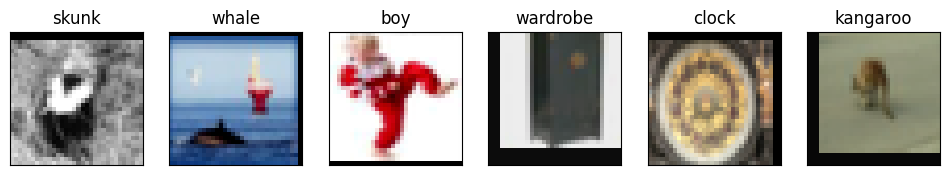

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def convert_to_imshow_format(image):
    # first convert back to [0,1] range from [-1,1] range
    image = image / 2 + 0.5
    image = image.numpy()
    # convert from CHW to HWC
    # from 3x32x32 to 32x32x3
    return image.transpose(1,2,0)

temp_loader = torch.utils.data.DataLoader(train_set, batch_size=30, shuffle=True)

dataiter = iter(temp_loader)
images, labels = next( dataiter )

images = images[:6]
labels = labels[:6]

fig, axes = plt.subplots(1, len(images), figsize=(12,2.5))
for idx, image in enumerate(images):
    axes[idx].imshow(convert_to_imshow_format(image))
    axes[idx].set_title(classes[labels[idx]])
    axes[idx].set_xticks([])
    axes[idx].set_yticks([])

### Specify a model architecture
---


In [ ]:
# [ 변경 기록 ]

# 변경1: 64.97%
# 채널 수 증가: 모든 Conv 층에서 채널 수를 256으로 증가시킴.
# Conv 층 수 증가: Conv 층을 3개에서 5개로 늘림.
# Batch Normalization 추가: 각 Conv 층 뒤에 BatchNorm을 추가하여 학습 안정성을 높임.
# Max Pooling 층 추가: Max Pooling 층을 추가로 사용하여 출력 크기를 4x4까지 줄임.
# 배치 사이즈 증가: 10 → 128
# 학습률 감소: 0.01 → 0.001
# 에폭 수 증가: 10 → 50

# 변경2: 60.51% (중단)
# 채널 수 증가: 모든 Conv 층에서 채널 수를 128으로 증가시킴.
# Batch Normalization 추가: 각 Conv 층 뒤에 BatchNorm을 추가하여 학습 안정성을 높임.
# Max Pooling 층 추가: Max Pooling 층을 추가로 사용하여 출력 크기를 4x4까지 줄임.
# 배치 사이즈 증가: 10 → 128
# 학습률 감소: 0.01 → 0.001
# 에폭 수 증가: 10 → 100

# 변경3: 66.94%
# 채널 수 증가: 모든 Conv 층에서 채널 수를 256으로 증가시킴.
# Conv 층 수 증가: Conv 층을 3개에서 6개로 늘림.
# Batch Normalization 추가: 각 Conv 층 뒤에 BatchNorm을 추가하여 학습 안정성을 높임.
# Max Pooling 층 추가: Max Pooling 층을 추가로 사용하여 출력 크기를 4x4까지 줄임.
# 배치 사이즈 증가: 10 → 128
# 학습률 감소: 0.01 → 0.0005
# 에폭 수 증가: 10 → 50





In [ ]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv_layers = nn.Sequential(
            # 채널 3 -> 256
            nn.Conv2d(in_channels=3, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 이미지 크기 절반으로 -> 16x16

            # 채널 256 -> 256
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            # 채널 256 -> 256
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            # 채널 256 -> 256
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            # 채널 256 -> 256
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 이미지 크기 절반으로 -> 8x8

            # 채널 256 -> 256
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 이미지 크기 절반으로 -> 4x4
        )

        self.fc_layers = nn.Sequential(
            # fc layer의 입력 노드 수 = 최종 채널 x 이미지 크기 = 256 x 4 x 4
            nn.Linear(256 * 4 * 4, 100),    # 마지막 fc layer의 출력 노드 수는 100
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # flatten
        x = self.fc_layers(x)
        return x

In [ ]:
# 모델 테스트
# 랜덤한 값으로 만든 이미지를 모델에 통과시켜 본 후 결과 텐서의 사이즈가 (7, 100)이 나오는지 확인된다면 OK.
# 이 코드가 에러가 나는 경우 Conv2d의 채널 수가 맞는지 fc layer의 노드 수가 맞는지 확인 필요

# 배치사이즈 7
# RGB 3채널
# 이미지 사이즈 32x32
# 랜덤값의 입력 데이터를 모델에 통과시켜 결과 모양을 확인

temp = SimpleCNN()
output = torch.randn( 7, 3, 32, 32)

print( temp(output).size() )


torch.Size([7, 100])


### Hyperparameters
---


In [ ]:
# 하이퍼파라미터

######## 수정 가능

batch_size = 64 # 배치 사이즈 (한번에 몇 개의 이미지를 배치로 학습할지)
learning_rate = 0.0005 # 학습률 (학습 진행 스텝의 크기)
num_epochs = 50 # 에폭 수 (데이터셋 한번 학습 단위, 얼마나 학습을 반복할 것인지)

### Setup the data loaders
---


In [ ]:
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)



### Instantiate the model
---

In [ ]:
model = SimpleCNN()

model.to(device)


SimpleCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, 

### Train the model
---


In [ ]:
# optimizer 방식을 변경 원하는 경우 변경 가능

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)


In [ ]:
from statistics import mean

def train(optimizer, model, num_epochs=10, first_epoch=1):

    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_losses = []

    # Best test accuracy
    best_test_acc = 0

    # Checkpoint #

    for epoch in range(first_epoch, first_epoch + num_epochs):
        print('Epoch', epoch)

        # train phase
        model.train()

        # create a progress bar
        progress = ProgressMonitor(length=len(train_set))

        # keep track of predictions
        correct_train = 0

        batch_losses = []

        for batch, targets in train_loader:

            # Move the training data to the GPU
            batch = batch.to(device)
            targets = targets.to(device)

            # clear previous gradient computation
            optimizer.zero_grad()

            # forward propagation
            outputs = model(batch)

            # calculate the loss
            loss = criterion(outputs, targets)

            # backpropagate to compute gradients
            loss.backward()

            # update model weights
            optimizer.step()

            batch_losses.append(loss.item())

            # accumulate correct count
            _, preds = torch.max(outputs, 1)
            correct_train += torch.sum(preds == targets.data)

            # update progress bar
            progress.update(batch.shape[0], mean(batch_losses) )


        train_losses.append( mean(batch_losses))


        # test phase
        model.eval()

        y_pred = []

        correct_test = 0

        # We don't need gradients for test, so wrap in
        # no_grad to save memory
        with torch.no_grad():

            for batch, targets in test_loader:

                # Move the training batch to the GPU
                batch = batch.to(device)
                targets = targets.to(device)

                # forward propagation
                outputs = model(batch)

                # calculate the loss
                loss = criterion(outputs, targets)

                # save predictions
                y_pred.extend( outputs.argmax(dim=1).cpu().numpy() )

                # accumulate correct count
                _, preds = torch.max(outputs, 1)
                correct_test += torch.sum(preds == targets.data)


        # Calculate accuracy
        train_acc = correct_train.item() / train_set.data.shape[0]
        test_acc = correct_test.item() / test_set.data.shape[0]


        print('Training accuracy: {:.2f}%'.format(float(train_acc) * 100))
        print('Test accuracy: {:.2f}%'.format(float(test_acc) * 100), end='')

        # Save the best model
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save( model.state_dict(), 'best_model.pt' )
            print( ' --> Best model saved!\n' )

         # Save the checkpoint
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "test_acc": test_acc,
            },
            f"{checkpoint_dir}/checkpoint-{epoch}.pt",
        )
        print( f'checkpoint-{epoch}.pt saved in Google Drive/checkpoint\n')

    return train_losses, test_losses, y_pred

### Checkpointing
---

In [ ]:
# (1) 처음부터 훈련 시작

train_losses, test_losses, y_pred = train(optimizer, model, num_epochs=num_epochs)

Epoch 1


Loss: 3.7194 50000 / 50000,50000


Training accuracy: 13.85%
Test accuracy: 22.84% --> Best model saved!

checkpoint-1.pt saved in Google Drive/checkpoint

Epoch 2


Loss: 2.8453 50000 / 50000,50000


Training accuracy: 28.68%
Test accuracy: 36.77% --> Best model saved!

checkpoint-2.pt saved in Google Drive/checkpoint

Epoch 3


...

Training accuracy: 92.72%
Test accuracy: 66.58%checkpoint-48.pt saved in Google Drive/checkpoint

Epoch 49


Loss: 0.2218 50000 / 50000,50000


Training accuracy: 92.90%
Test accuracy: 66.04%checkpoint-49.pt saved in Google Drive/checkpoint

Epoch 50


Loss: 0.2151 50000 / 50000,50000


Training accuracy: 93.04%
Test accuracy: 66.87%checkpoint-50.pt saved in Google Drive/checkpoint



In [ ]:
# (2) 기존의 체크포인트에서 이어서 훈련할 때 이 코드셀을 실행

# 원하는 체크포인트 파일 지정

LOAD_FROM_CHECKPOINT = False

if LOAD_FROM_CHECKPOINT:

    try:

        checkpoint_file = 'checkpoint-3.pt'

        checkpoint = torch.load( f'{checkpoint_dir}/{checkpoint_file}')

        if checkpoint:
            model.load_state_dict(checkpoint["model_state_dict"])
            optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
            saved_epoch = checkpoint["epoch"]

            print( '*' * 80)
            print( f'***** {checkpoint_file} loaded. *****')
            print( f'Test accuracy - {checkpoint["test_acc"]}')
            print( f'Saved epoch - {saved_epoch}')
            print( '*' * 80, '\n')

    except:

        print('체크포인트를 로드할 수 없습니다!!.\n불러오려는 체크포인트 파일이 있는지 확인해보세요.\n만약 모델 구조를 변경했다면 처음부터 다시 훈련해야 합니다.\n')


    # 이어서 훈련 시작
    train_losses, test_losses, y_pred = train(optimizer, model, num_epochs=num_epochs, first_epoch=saved_epoch+1)


### Make a CSV for submission
---

In [ ]:
# Load the best model
# 훈련을 진행하면서 제일 성능이 좋았던 모델을 load

model = SimpleCNN()
model.load_state_dict( torch.load('best_model.pt') )
model.to(device)


<ipython-input-58-4c3a12c9999c>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict( torch.load('best_model.pt') )


SimpleCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, 

In [ ]:
# 모델 성능 테스트

# test phase
model.eval()

# keep track of predictions
y_pred = []

# We don't need gradients for test, so wrap in
# no_grad to save memory
with torch.no_grad():

    for batch, targets in test_loader:

        # Move the training batch to the GPU
        batch = batch.to(device)
        targets = targets.to(device)

        # forward propagation
        predictions = model(batch)

        # save predictions
        y_pred.extend( predictions.argmax(dim=1).cpu().numpy() )



In [ ]:
# 모델 테스트 결과를 cifar100_submit.csv로 저장
# 이 코드셀 실행 후 왼쪽의 파일 탭을 열어 cifar100_submit.csv 를 오른쪽 클릭 후 다운로드

import csv

def make_pred_csv(model):
    with open('cifar100_submit.csv', mode='w') as pred_file:

        pred_writer = csv.writer(pred_file, delimiter=',')
        pred_writer.writerow(['id', 'Category'])

        for i, label in enumerate(y_pred):
            pred_writer.writerow([i+1, classes[label]])


make_pred_csv(model)

## 제출 방법

---

#### 1) CSV Download

---


- 위의 Make a CSV for submission 항목의 코드셀들을 실행
- 왼쪽의 폴더 버튼을 클릭한 후 나오는 Files 패널에서 **cifar100_submit.csv** 확인 (보이지 않을 경우 refresh 아이콘 클릭)
- 파일을 오른쪽 클릭하여 다운로드


---


#### 2) Kaggle에 .csv 제출

---

- Kaggle Competition 링크로 이동: https://www.kaggle.com/competitions/2024-2-cifar-100-competition
- Kaggle 계정이 없는 경우 register, 만약 있으면 login.

- Team 탭을 클릭하여 이름을 '분반 학번 이름' (예) **01분반 202012345 김연세**) 으로 변경

- 다운로드 했던 .csv 파일을 제출 (마감 전까지 제한 없이 제출하며 순위 갱신 가능)

- Leaderboard에 본인 이름 확인

---

#### 3) LearnUs에 .ipynb 제출

---

- Kaggle에 최종 .csv 제출을 마쳤으면,
- LearnUs 12주차 과제항목 AI07a (Kaggle)에 이 노트북 (.ipynb)을 제출


#### * GPU 시간 제한 문제를 피하기 위해

- 노트북을 그냥 종료하면 런타임이 여전히 할당되어 있는채로 끝날 수 있기 때문에 항상 오른쪽 상단의 Ram/Disk 오른쪽 화살표 버튼을 클릭하여 Disconnect and delete runtime을 누른 후 종료해주세요.
(https://www.reddit.com/r/PygmalionAI/comments/11yr7nk/psa_how_to_avoid_hitting_gpu_rate_limit_on_colab/)

#### * 계정의 GPU 할당 시간이 다 소모된 경우
- 새로운 구글 계정을 생성 후 노트북 오른쪽 상단의 공유(Share) 메뉴를 열어 새로운 계정을 편집자(Editor)로 추가하여 상황에 따라 계정을 전환하며 훈련